### Загрузка данных

библиотеки

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

фаил

In [2]:
df = pd.read_csv('train.csv')

### Знакомство с датасетом

Определяем количество строк и столбцов

In [27]:
df.shape

(891, 13)

Выводим названия всех столбцов

In [26]:
df.columns.tolist()

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked',
 'AgeGroup']

Смотрим типы данных столбцов

In [25]:
df.dtypes

PassengerId       int64
Survived          int64
Pclass            int64
Name             object
Sex              object
Age             float64
SibSp             int64
Parch             int64
Ticket           object
Fare            float64
Cabin            object
Embarked         object
AgeGroup       category
dtype: object

 ### Анализ пассажиров

Количество пассажиров каждого класса

In [24]:
df['Pclass'].value_counts().sort_index()

Pclass
1    216
2    184
3    491
Name: count, dtype: int64

Количество мужчин и женщин

In [23]:
df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

Разделяем пассажиров на возрастные группы

In [21]:
bins = [0, 12, 18, 35, 60, 100]
labels = ['Дети (0-12)', 'Подростки (13-18)', 'Молодые (19-35)', 'Взрослые (36-60)', 'Пожилые (60+)']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)
df['AgeGroup'].value_counts(dropna=False)

AgeGroup
Молодые (19-35)      366
Взрослые (36-60)     209
NaN                  177
Дети (0-12)           68
Подростки (13-18)     45
Пожилые (60+)         26
Name: count, dtype: int64

Средний возраст пассажиров

In [19]:
round(df['Age'].mean(), 2)

29.7

Медианный возраст пассажиров

In [18]:
 df['Age'].median()

28.0

Средняя стоимость билета

In [17]:
round(df['Fare'].mean(), 2)

32.2

### Сравнение пассажиров разных классов

Средняя стоимость билета для 1, 2 и 3 классов

In [30]:
round(df.groupby('Pclass')['Fare'].mean(),2)

Pclass
1    84.15
2    20.66
3    13.68
Name: Fare, dtype: float64

Средний возраст пассажиров разных классов

In [31]:
round(df.groupby('Pclass')['Age'].mean(), 2))

# 14. Количество мужчин и женщин в каждом классе
print("\n14. Количество мужчин и женщин в каждом классе:\n", df.groupby(['Pclass', 'Sex']).size().unstack())

# 15. В каком классе было больше всего пассажиров
max_class = df['Pclass'].value_counts().idxmax()
print(f"\n15. Класс с наибольшим количеством пассажиров: {max_class}-й класс")

# 16. Небольшой вывод о различиях между классами
print("\n16. Вывод: Пассажиры 1-го класса платили за билеты в несколько раз больше и были в среднем старше. 3-й класс был самым многочисленным и включал больше мужчин, при этом средняя стоимость билета там была минимальной.")

# 17. Самый дорогой билет: класс, возраст, пол и факт выживания
idx_max_fare = df['Fare'].idxmax()
most_expensive = df.loc[idx_max_fare, ['Pclass', 'Age', 'Sex', 'Survived', 'Fare']]
print("\n17. Информация о самом дорогом билете:\n", most_expensive)

SyntaxError: unmatched ')' (4096018413.py, line 1)

Количество мужчин и женщин в каждом классе

In [34]:
 df.groupby(['Pclass', 'Sex']).size().unstack()

Sex,female,male
Pclass,,
1,94,122
2,76,108
3,144,347


В каком классе было больше всего пассажиров

In [35]:
max_class = df['Pclass'].value_counts().idxmax()
{max_class} 

{3}

Небольшой вывод о различиях между классами

Вывод: Пассажиры 1-го класса платили за билеты в несколько раз больше и были в среднем старше. 3-й класс был самым многочисленным и включал больше мужчин, при этом средняя стоимость билета там была минимальной.

 Самый дорогой билет: класс, возраст, пол и факт выживания

In [37]:
idx_max_fare = df['Fare'].idxmax()
most_expensive = df.loc[idx_max_fare, ['Pclass', 'Age', 'Sex', 'Survived', 'Fare']]
print( most_expensive)

Pclass             1
Age             35.0
Sex           female
Survived           1
Fare        512.3292
Name: 258, dtype: object


### Анализ выживаемости

Общее количество выживших (1) и погибших (0)

In [38]:
 df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

Сравнение выживаемости мужчин и женщин

In [41]:
survival_by_sex = df.groupby('Sex')['Survived'].mean()
round(survival_by_sex, 3)

Sex
female    0.742
male      0.189
Name: Survived, dtype: float64

Выживаемость мужчин и женщин для каждого класса

In [43]:
survival_by_class_sex = df.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack()
round(survival_by_class_sex, 3)

Sex,female,male
Pclass,,
1,0.968,0.369
2,0.921,0.157
3,0.500,0.135


Группа пассажиров с наибольшей долей выживших

In [44]:
best_survival_group = df.groupby(['Pclass', 'Sex'])['Survived'].mean().idxmax()
{best_survival_group[0]}, {best_survival_group[1]}

({1}, {'female'})

 Визуализация

График количества пассажиров по классам

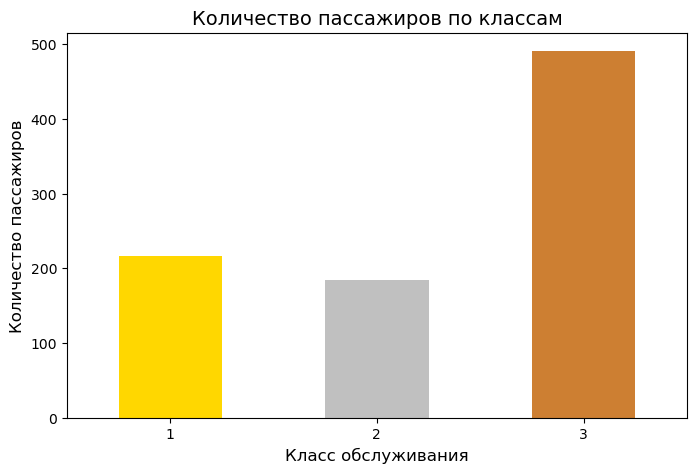

In [45]:
plt.figure(figsize=(8, 5))
df['Pclass'].value_counts().sort_index().plot(kind='bar', color=['#FFD700', '#C0C0C0', '#CD7F32'])
plt.title('Количество пассажиров по классам', fontsize=14)
plt.xlabel('Класс обслуживания', fontsize=12)
plt.ylabel('Количество пассажиров', fontsize=12)
plt.xticks(rotation=0)
plt.show()


График выживаемости по полу

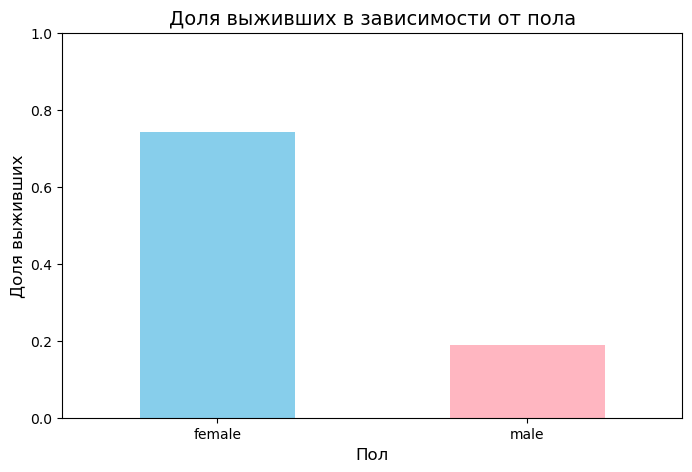

In [46]:
plt.figure(figsize=(8, 5))
survival_by_sex.plot(kind='bar', color=['#87CEEB', '#FFB6C1'])
plt.title('Доля выживших в зависимости от пола', fontsize=14)
plt.xlabel('Пол', fontsize=12)
plt.ylabel('Доля выживших', fontsize=12)
plt.xticks(rotation=0)
plt.ylim(0, 1) 
plt.show()

свой вопрос - какой средний возраст у выживших и у погибших пассажиров?


In [47]:
avg_age_by_survival = df.groupby('Survived')['Age'].mean()
avg_age_by_survival.index = ['Погибшие (0)', 'Выжившие (1)']